In [4]:
#Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
#Loading data. (renamed csv files for simplicity)
#Edit path to where datais stored on your computer.
test = 'C:/Users/firea/Desktop/CapstoneProject/data_analysis/churn_testing.csv'
train = 'C:/Users/firea/Desktop/CapstoneProject/data_analysis/churn_training.csv'


#------------------------------------------------------------
#For model evaluation
test_df = pd.read_csv(test)
train_df = pd.read_csv(train)

#For visual analysis
original_df = train_df.copy()

In [8]:
#Displays number of data entries and columns in dataset
train_df.shape

(440833, 12)

In [9]:
#column info
train_df.dtypes

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [10]:
test_df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [11]:
train_df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [ ]:
#Filters all datasets to drop all null values.
train_df = train_df.dropna()
train_df.isnull().sum()
original_df = original_df.dropna()

In [ ]:
#Drops unimportant columns
train_df = train_df.drop(columns=['CustomerID'], errors='ignore')
test_df  = test_df.drop(columns=['CustomerID'], errors='ignore')

#Converts columns to be numerical in preperation of executing the random forest classification model
train_df['Churn'] = (
    train_df['Churn']
    .replace({'Churned': 1, 'Active': 0})
    .astype(float)
    .astype(int)
)

test_df['Churn'] = (
    test_df['Churn']
    .replace({'Churned': 1, 'Active': 0})
    .astype(float)
    .astype(int)
)

train_df['Gender'] = (train_df['Gender'] == 'Female').astype(int)
test_df['Gender']  = (test_df['Gender'] == 'Female').astype(int)

sub_mapping = {
    'Standard':0,
    'Premium':1,
    'Other':2
}
train_df['Subscription Type'] = train_df['Subscription Type'].map(sub_mapping)
test_df['Subscription Type']  = test_df['Subscription Type'].map(sub_mapping)

contract_mapping = {
    'Annual': 0,
    'Quarterly': 1,
    'Other': 2
}
train_df['Contract Length'] = train_df['Contract Length'].map(contract_mapping)
test_df['Contract Length']  = test_df['Contract Length'].map(contract_mapping)


In [ ]:
#Preparing train test split for classification report 
from sklearn.metrics import classification_report
X_trn = train_df.drop(columns=['Churn'])
y_trn = train_df['Churn']

X_tst = test_df.drop(columns=['Churn'])
y_tst = test_df['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X_trn, y_trn, test_size=0.2, stratify=y_trn, random_state=42
)

#Initializing random forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
train_acc = rf.score(X_train, y_train)
val_acc   = rf.score(X_val, y_val)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

y_val_pred = rf.predict(X_val)
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))






In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
#Testing accuracy in another machine model
print("\n----- Logistic Regression -----")

X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_val = X_val.dropna()
y_val = y_val[X_val.index]

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

train_acc = lr.score(X_train, y_train)
val_acc   = lr.score(X_val, y_val)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

y_val_pred = lr.predict(X_val)
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))


----- Logistic Regression -----
Train Accuracy: 0.8685119662669213
Validation Accuracy: 0.8662372740494494
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     26346
           1       0.86      0.84      0.85     21784

    accuracy                           0.87     48130
   macro avg       0.87      0.86      0.86     48130
weighted avg       0.87      0.87      0.87     48130



In [ ]:
#Testing accuracy in gradient boosting
print("--------------------------------\n Gradient Boosting")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

print("Train Accuracy:", gb.score(X_train, y_train))
print("Validation Accuracy:", gb.score(X_val, y_val))

y_val_pred = gb.predict(X_val)
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))

--------------------------------
 Gradient Boosting
Train Accuracy: 0.9999739069626661
Validation Accuracy: 0.9999584458757532
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26346
           1       1.00      1.00      1.00     21784

    accuracy                           1.00     48130
   macro avg       1.00      1.00      1.00     48130
weighted avg       1.00      1.00      1.00     48130



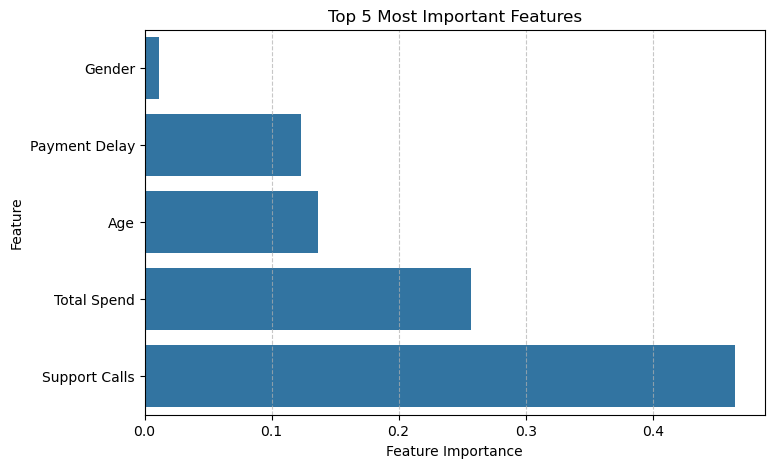

In [ ]:
#Sorting most important features
top5 = top5.sort_values(by='importance', ascending=True) 

plt.figure(figsize=(8,5))
sns.barplot(
    x='importance',
    y='feature',
    data=top5
)

plt.title('Top 5 Most Important Features')
plt.xlabel('Feature Importance (%)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

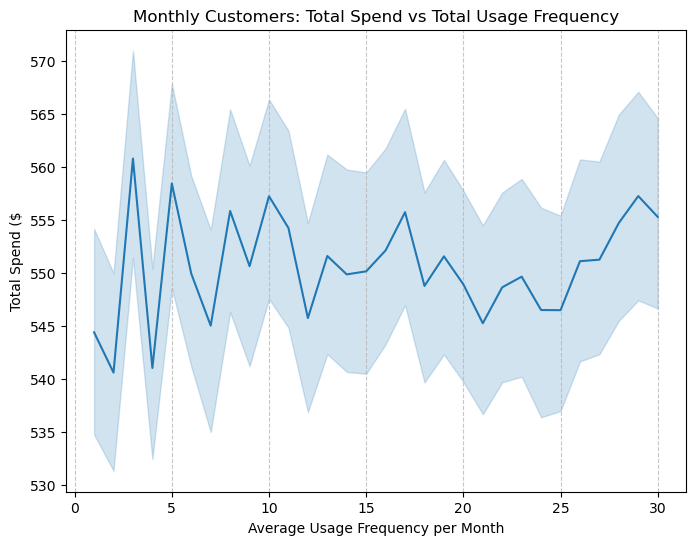

In [ ]:
#Showcases how much users spent vs how active they really were

monthly_df = original_df[original_df['Contract Length'] == 'Monthly']

plt.figure(figsize=(8,6))

sns.lineplot(
    data=monthly_df,
    x='Usage Frequency',
    y='Total Spend',
    estimator='mean'
)

plt.xlabel('Average Usage Frequency per Month')
plt.ylabel('Total Spend ($')
plt.title('Monthly Customers: Total Spend vs Total Usage Frequency')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

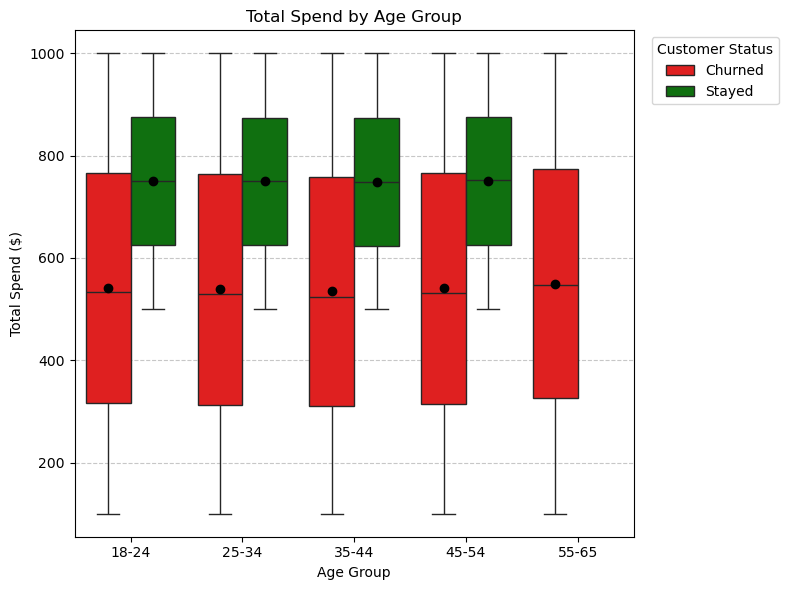

In [ ]:
#Showcases total spent by age group.
original_df['Churn Label'] = original_df['Churn'].map({
    0: 'Stayed',
    1: 'Churned'
})
original_df['Age Group'].value_counts(dropna=False)

age_bins = [18, 25, 35, 45, 55, 66]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-65']

original_df['Age Group'] = pd.cut(
    original_df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

churn_colors = {
    'Stayed': 'green',
    'Churned': 'red'
}

plt.figure(figsize=(8,6))

sns.boxplot(
    data=original_df,
    x='Age Group',
    y='Total Spend',
    hue='Churn Label',
    palette=churn_colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black"
    }
)

plt.title('Total Spend by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Spend ($)')

plt.legend(
    title='Customer Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Easier to see mean averages.
original_df.groupby('Age Group')['Total Spend'].mean()

C:\Users\firea\AppData\Local\Temp\ipykernel_10436\1104772877.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  original_df.groupby('Age Group')['Total Spend'].mean()


Age Group
18-24    631.871562
25-34    644.296677
35-44    656.530745
45-54    638.815679
55-65    549.215247
Name: Total Spend, dtype: float64

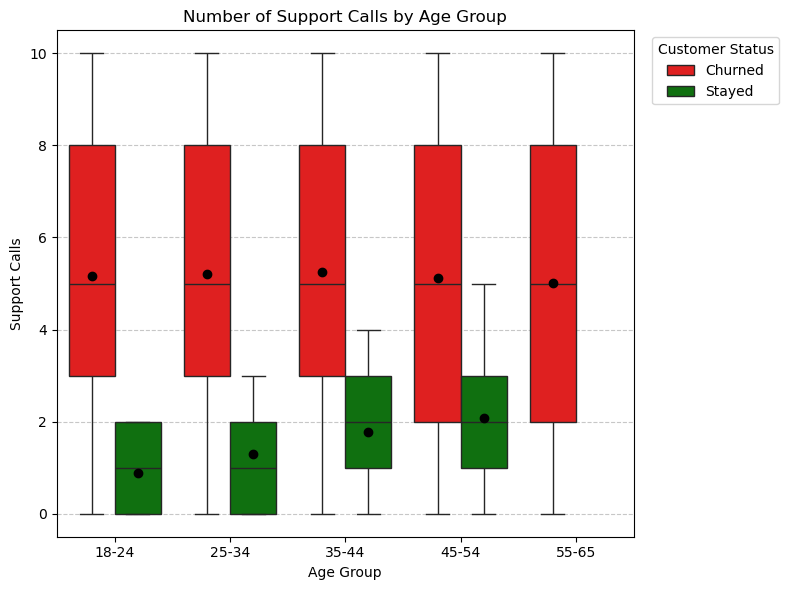

In [ ]:
original_df['Churn Label'] = original_df['Churn'].map({
    0: 'Stayed',
    1: 'Churned'
})
original_df['Age Group'].value_counts(dropna=False)

age_bins = [18, 25, 35, 45, 55, 66]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-65']

original_df['Age Group'] = pd.cut(
    original_df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

churn_colors = {
    'Stayed': 'green',
    'Churned': 'red'
}

plt.figure(figsize=(8,6))

sns.boxplot(
    data=original_df,
    x='Age Group',
    y='Support Calls',
    hue='Churn Label',
    palette=churn_colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black"
    }
)

plt.title('Number of Support Calls by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Support Calls')

plt.legend(
    title='Customer Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------- User input for subscription churn predictions

In [2]:
print("Please enter your details to predict churn probability.")
original_df = original_df.drop(columns=['CustomerID'], errors='ignore')

Please enter your details to predict churn probability.
